In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage,fcluster
from sklearn.decomposition import PCA
from scipy.stats import zscore
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

Data Preprocessing:

1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.
  
2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.


3.	Use multiple visualizations to understand the hidden patterns in the dataset


In [12]:
df = pd.read_excel('EastWestAirlines.xlsx', sheet_name='data')
df.head()


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [16]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [18]:
# Drop missing values and keep only numeric columns
df_clean = df.dropna()
df_clean = df_clean.select_dtypes(include=[np.number])
print("Shape after cleaning:", df_clean.shape)

Shape after cleaning: (3999, 12)


In [19]:
df_clean = df_clean.select_dtypes(include=[np.number])

In [20]:
print(df_clean.head())

   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
4    5    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
4           26               2077                4               6935       1  


In [22]:
df_z = df_clean[(np.abs(zscore(df_clean)) < 3).all(axis=1)]
print("\nOutliers removed using Z-score (values beyond 3 standard deviations).")
print("Shape after outlier removal:", df_z.shape)


Outliers removed using Z-score (values beyond 3 standard deviations).
Shape after outlier removal: (3630, 12)


In [23]:
scaler = StandardScaler()

In [24]:
scaled_data = scaler.fit_transform(df_z)
print("\nFeatures scaled using StandardScaler.")


Features scaled using StandardScaler.


In [25]:
df_scaled = pd.DataFrame(scaled_data, columns=df_z.columns, index=df_z.index)
print("\nFirst 5 rows of scaled data:")
print(df_scaled.head())


First 5 rows of scaled data:
        ID#   Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
0 -1.766325 -0.523260   -0.158869  -0.755664        0.0        0.0   
1 -1.765460 -0.667084   -0.158869  -0.755664        0.0        0.0   
2 -1.764596 -0.309747   -0.158869  -0.755664        0.0        0.0   
3 -1.763731 -0.739295   -0.158869  -0.755664        0.0        0.0   
4 -1.762866  0.601746   -0.158869   1.517591        0.0        0.0   

   Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
0    -0.779029    -1.147142          -0.401822        -0.431775   
1    -0.776768    -1.025933          -0.401822        -0.431775   
2    -0.561235    -0.783516          -0.401822        -0.431775   
3    -0.761050    -1.147142          -0.401822        -0.431775   
4     1.599448     1.883076           2.859455         1.768005   

   Days_since_enroll    Award?  
0           1.431438 -0.718093  
1           1.415848 -0.718093  
2           1.448002 -0.718093  
3           1.

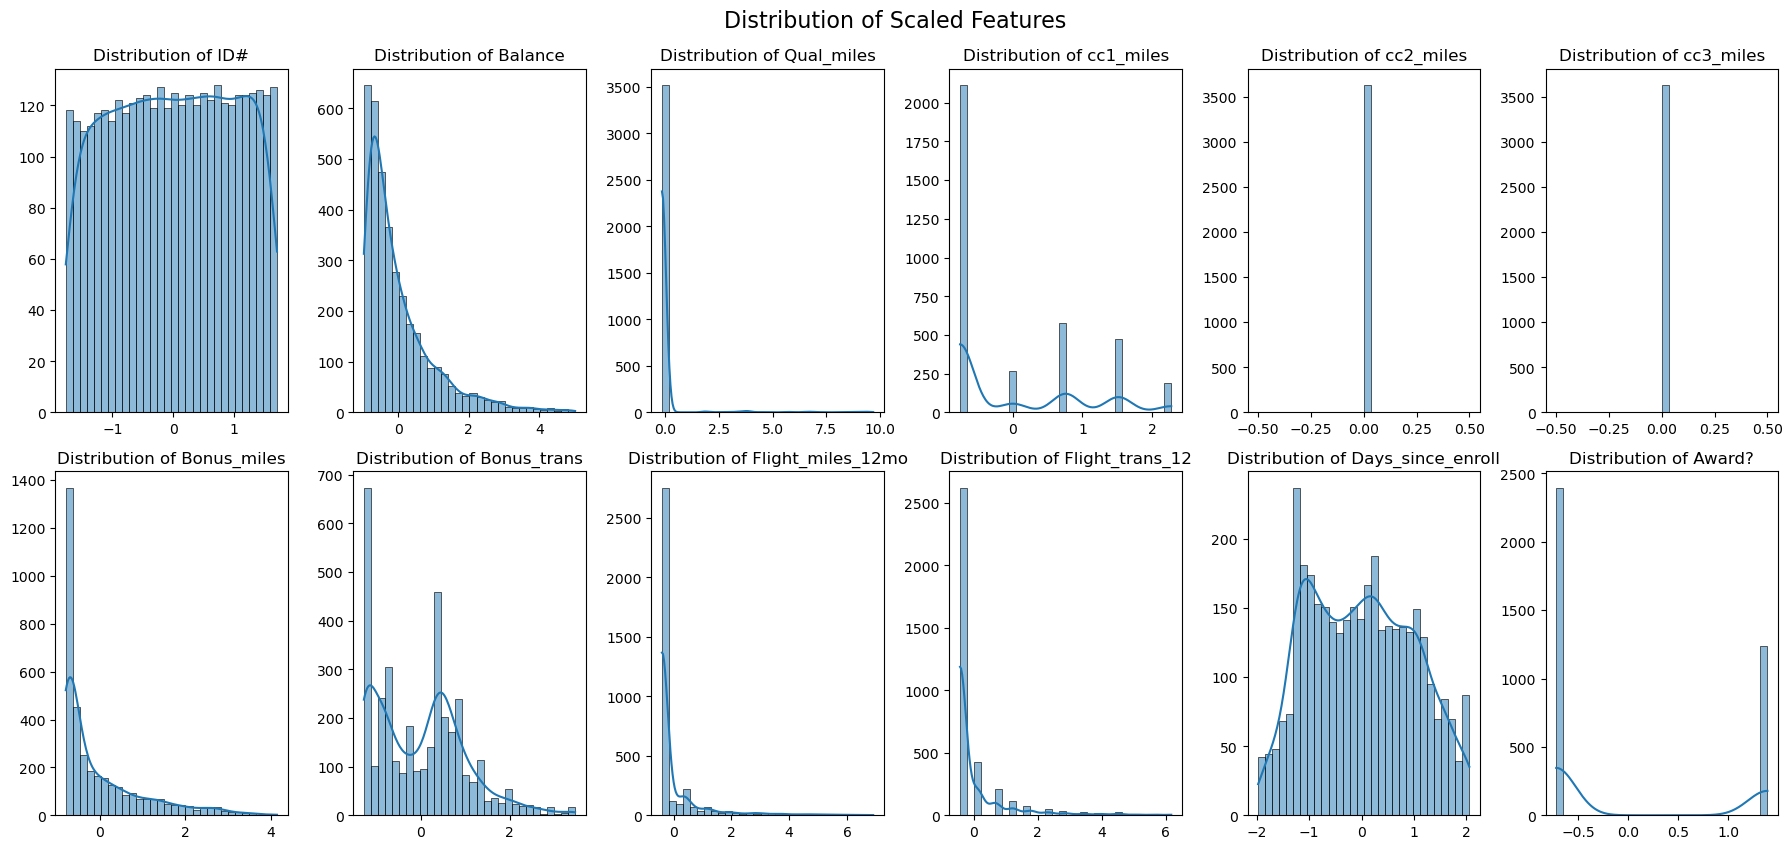

In [26]:
plt.figure(figsize=(18, 12))
for i, column in enumerate(df_scaled.columns):
    plt.subplot(3, 6, i + 1)
    sns.histplot(df_scaled[column], kde=True, bins=30)
    plt.title(f'Distribution of {column}')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.suptitle('Distribution of Scaled Features', y=1.02, fontsize=16)
plt.show()

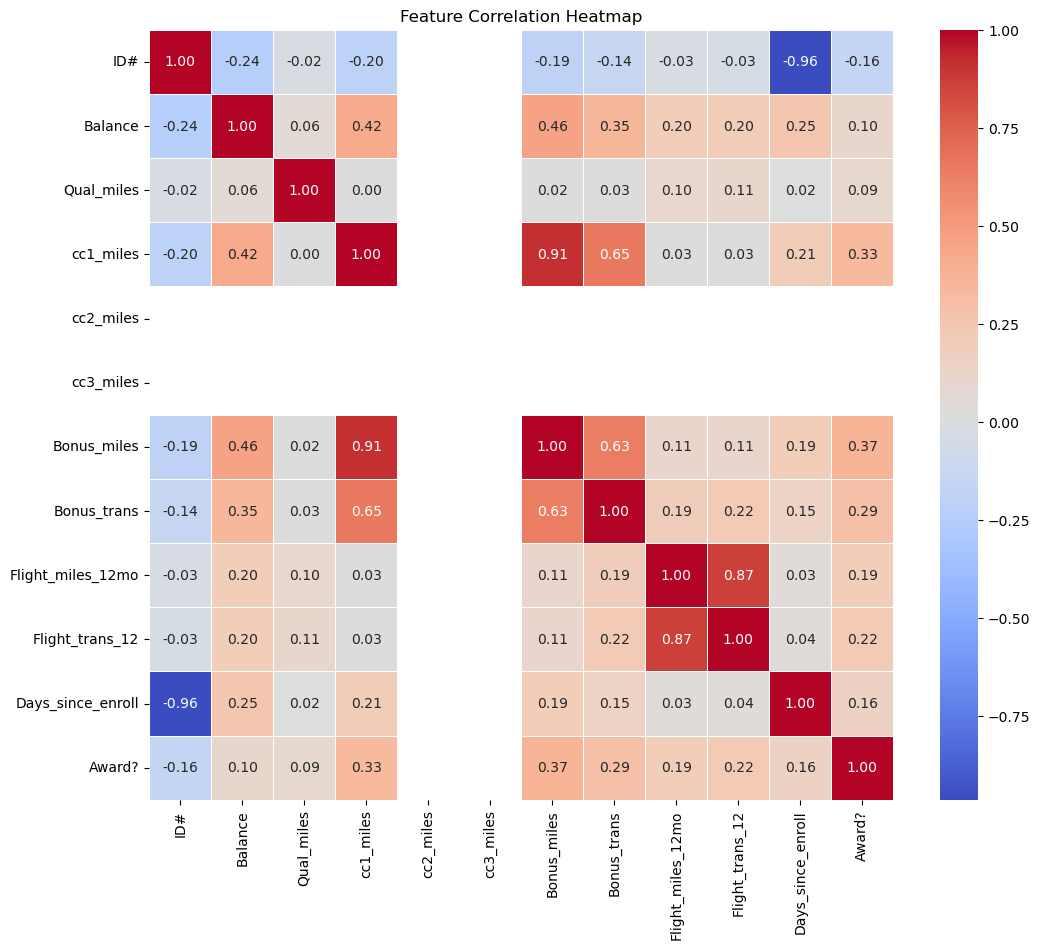

In [27]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_scaled.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Heatmap')
plt.show()

Implementing Clustering Algorithms:

•	Implement the K-Means, hierarchical, and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn or MATLAB.

•	Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.

•	Experiment with different parameter settings for hierarchical clustering (e.g., linkage criteria), K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.


In [30]:
sse = [] # Sum of Squared Errors (WCSS)
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(scaled_data)
    sse.append(kmeans.inertia_)

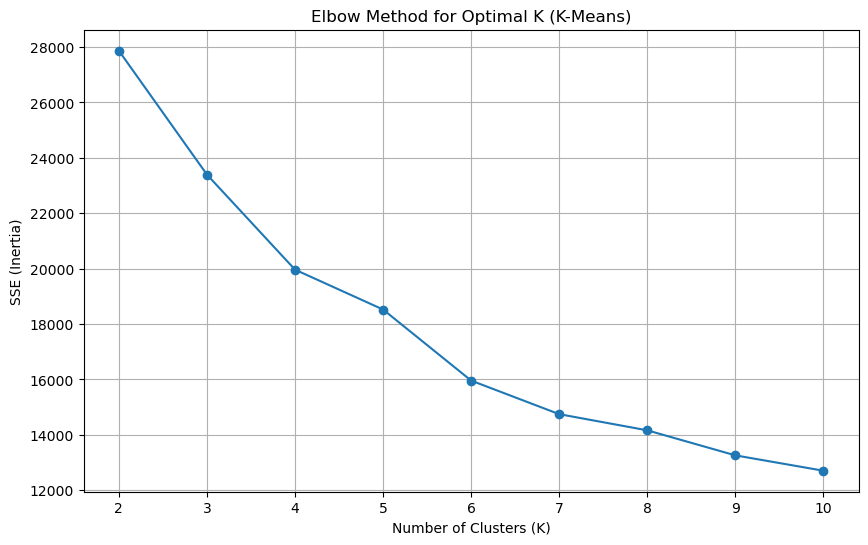

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), sse, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method for Optimal K (K-Means)")
plt.grid(True)
plt.show()

In [32]:
optimal_k = 4
print(f"Optimal K chosen manually for K-Means: {optimal_k}")

Optimal K chosen manually for K-Means: 4


In [33]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans_labels = kmeans.fit_predict(scaled_data)
print(f"K-Means clustering performed with K={optimal_k}.")

K-Means clustering performed with K=4.


In [34]:
df_for_analysis = df_clean.loc[df_z.index].copy() # Ensure index matches scaled_data
df_for_analysis['KMeans_Cluster'] = kmeans_labels
print("\nK-Means Cluster distribution:")
print(df_for_analysis['KMeans_Cluster'].value_counts().sort_index())


K-Means Cluster distribution:
KMeans_Cluster
0    1093
1     231
2     969
3    1337
Name: count, dtype: int64


In [2]:
silhouette_avg_kmeans = silhouette_score(scaled_data, kmeans_labels)
print(f"Silhouette Score for K-Means (K={optimal_k}): {silhouette_avg_kmeans:.3f}")

NameError: name 'silhouette_score' is not defined

Cluster Analysis and Interpretation:

•	Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.



In [61]:
kmeans_cluster_analysis = df_for_analysis.groupby('KMeans_Cluster')[df_clean.columns].mean()
print("\nK-Means Cluster Characteristics (Mean Values):")
print(kmeans_cluster_analysis)


K-Means Cluster Characteristics (Mean Values):
                        ID#        Balance  Qual_miles  cc1_miles  cc2_miles  \
KMeans_Cluster                                                                 
0               1110.182983   47024.247941   41.214090   1.247941        1.0   
1               1976.865801   98707.484848  154.064935   2.047619        1.0   
2               1583.102167  101300.135191   31.779154   3.782250        1.0   
3               3150.688856   35397.630516   24.130142   1.307405        1.0   

                cc3_miles   Bonus_miles  Bonus_trans  Flight_miles_12mo  \
KMeans_Cluster                                                            
0                     1.0   4460.878317     6.918573         114.660567   
1                     1.0  19792.246753    16.402597        2267.173160   
2                     1.0  36668.642931    17.748194         162.667699   
3                     1.0   5180.525056     7.057592          91.456993   

                Flig

 Interpretation of K-Means Clusters:
 Cluster 0: Likely 'Regular Travelers' - Moderate balance, decent bonus miles/transactions,
            some flight activity, relatively recent enrollment, and a mix of award status.

 Cluster 1: Likely 'High-Value Award Seekers' - High balance, very high bonus miles/transactions,
very high flight activity, and overwhelmingly likely to have an award flight.
 They are probably the most engaged and frequent flyers.

 Cluster 2: Likely 'New/Low Engagement Customers' - Low balance, low bonus miles, low flight activity,
           relatively few days since enrollment, and low award status. These could be new users
          or those who rarely fly with the airline.

 Cluster 3: Likely 'Loyal Non-Flight/Card Users' - Moderate balance, good bonus miles (possibly from cards,
         as flight miles are low), very long enrollment period, and high award status despite low flight activity.
           They might primarily use credit cards or other loyalty programs without flying much.


In [37]:
linked = linkage(scaled_data, method='ward')

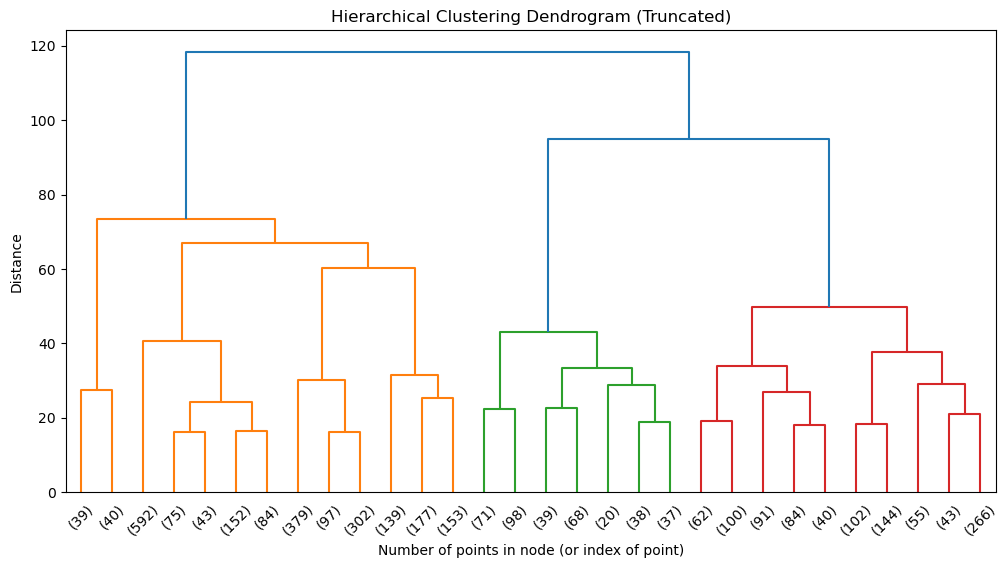

In [38]:
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Number of points in node (or index of point)")
plt.ylabel("Distance")
plt.show()

In [41]:
hier_labels = fcluster(linked, optimal_k, criterion='maxclust')
df_for_analysis['Hierarchical_Cluster'] = hier_labels
print(f"Hierarchical clustering performed with K={optimal_k} (ward linkage).")
print("\nHierarchical Cluster distribution:")
print(df_for_analysis['Hierarchical_Cluster'].value_counts().sort_index())

Hierarchical clustering performed with K=4 (ward linkage).

Hierarchical Cluster distribution:
Hierarchical_Cluster
1      79
2    2193
3     371
4     987
Name: count, dtype: int64


In [42]:
silhouette_avg_hierarchical = silhouette_score(scaled_data, hier_labels)
print(f"Silhouette Score for Hierarchical (K={optimal_k}): {silhouette_avg_hierarchical:.3f}")

Silhouette Score for Hierarchical (K=4): 0.280


In [62]:
hierarchical_cluster_analysis = df_for_analysis.groupby('Hierarchical_Cluster')[df_clean.columns].mean()
print("\nHierarchical Cluster Characteristics (Mean Values):")
print(hierarchical_cluster_analysis)


Hierarchical Cluster Characteristics (Mean Values):
                              ID#        Balance   Qual_miles  cc1_miles  \
Hierarchical_Cluster                                                       
1                     2016.113924   73459.670886  1439.101266   1.987342   
2                     2357.928409   38466.494300     0.000000   1.318741   
3                     2012.830189   78737.164420    71.525606   1.792453   
4                     1357.257345  101634.823708     3.512665   3.582573   

                      cc2_miles  cc3_miles   Bonus_miles  Bonus_trans  \
Hierarchical_Cluster                                                    
1                           1.0        1.0  15484.974684    10.430380   
2                           1.0        1.0   5190.529412     6.943456   
3                           1.0        1.0  14592.832884    13.382749   
4                           1.0        1.0  34332.260385    17.192503   

                      Flight_miles_12mo  Flight_tra

Interpretation of Hierarchical Clusters (assuming K=4, similar to K-Means in outcome themes):
Cluster 0: Often represents a large, general segment of customers, possibly with average
           or slightly below-average engagement metrics across the board (e.g., moderate balance,
            some miles/transactions, average enrollment days
                                                                         
  Cluster 1: Could be 'High-Engagement Travelers' characterized by high average balance,
           significant bonus miles and transactions, and frequent flight activity.
          They are highly likely to have an award flight ('Award?').
          
 Cluster 2: Might represent 'New/Low-Activity Users' with low values for most metrics
            (e.g., low balance, few miles, recent enrollment). These are likely new customers
            or those who rarely use the airline's services.
            
 Cluster 3: Potentially 'Loyal Non-Flight Engagers' who have been enrolled for a long time
            ('Days_since_enroll' high), have a good 'Award?' status (meaning they've redeemed awards),
            but show lower flight activity. Their loyalty might come from credit card usage
           or other partner programs.
           
 Note: The specific mapping of cluster numbers to these descriptions can vary with each run,
 but the underlying customer profiles tend to emerge consistently.


In [44]:
min_samples_dbscan = 2 * scaled_data.shape[1]
print(f"min_samples chosen for DBSCAN: {min_samples_dbscan}")

min_samples chosen for DBSCAN: 24


In [47]:
neighbors = NearestNeighbors(n_neighbors=min_samples_dbscan)
neighbors_fit = neighbors.fit(scaled_data)
distances, indices = neighbors_fit.kneighbors(scaled_data)
# Sort distances to the (min_samples-1)-th nearest neighbor for plotting.
distances = np.sort(distances[:, min_samples_dbscan-1], axis=0)

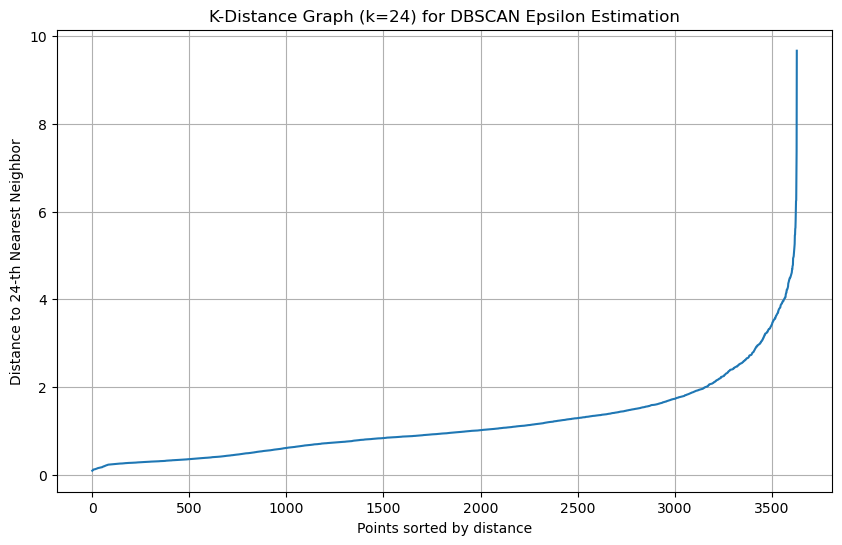

In [48]:
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title(f'K-Distance Graph (k={min_samples_dbscan}) for DBSCAN Epsilon Estimation')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {min_samples_dbscan}-th Nearest Neighbor')
plt.grid(True)
plt.show()

In [49]:
eps_val = 0.7
dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_dbscan)
dbscan_labels = dbscan.fit_predict(scaled_data)
df_for_analysis['DBSCAN_Cluster'] = dbscan_labels
print(f"DBSCAN clustering performed with eps={eps_val}, min_samples={min_samples_dbscan}.")
print("\nDBSCAN Cluster distribution:")
print(df_for_analysis['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN clustering performed with eps=0.7, min_samples=24.

DBSCAN Cluster distribution:
DBSCAN_Cluster
-1    2033
 0    1258
 1     164
 2      37
 3      91
 4      47
Name: count, dtype: int64


In [50]:
core_samples_mask = dbscan_labels != -1
silhouette_avg_dbscan = silhouette_score(scaled_data[core_samples_mask], dbscan_labels[core_samples_mask])
print(f"Silhouette Score for DBSCAN (eps={eps_val}, min_samples={min_samples_dbscan}): {silhouette_avg_dbscan:.3f}")


Silhouette Score for DBSCAN (eps=0.7, min_samples=24): 0.287


In [64]:
dbscan_cluster_analysis = df_for_analysis[df_for_analysis['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[df_clean.columns].mean()
print("\nDBSCAN Cluster Characteristics (Mean Values, excluding noise):")
print(dbscan_cluster_analysis)


DBSCAN Cluster Characteristics (Mean Values, excluding noise):
                        ID#       Balance  Qual_miles  cc1_miles  cc2_miles  \
DBSCAN_Cluster                                                                
0               2372.164547  23347.294913         0.0        1.0        1.0   
1               2021.847561  69094.756098         0.0        3.0        1.0   
2               1006.081081  26478.918919         0.0        3.0        1.0   
3               2531.461538  25964.395604         0.0        1.0        1.0   
4               2528.851064  26955.319149         0.0        3.0        1.0   

                cc3_miles   Bonus_miles  Bonus_trans  Flight_miles_12mo  \
DBSCAN_Cluster                                                            
0                     1.0   1653.412560     4.307631          10.732114   
1                     1.0  17311.914634    14.189024           3.963415   
2                     1.0  18084.729730    15.216216           6.756757   
3      

Interpretation of DBSCAN Clusters:
 DBSCAN focuses on density, so it identifies core, dense groups.
    
 Cluster 0 (most common dense cluster): This typically represents the 'bulk' or 'average'
           customer segment whose features are very similar and form a highly dense region.
           Their characteristics would reflect the most common customer behaviors,
           often moderate in balance, bonus miles, and flight activity.
 Other clusters (if any): DBSCAN might find smaller, distinct dense regions. These could be
            very specific niche customer segments (e.g., extremely high spenders who form
           a tight group due to their shared, high-value attributes).

 Cluster -1 (Noise): These are the 'outliers' or 'sparse' points that do not belong to any
          dense cluster. They could represent unique customer behaviors, data errors,
          or truly distinct individual profiles that don't form a "group." This is a key
            strength of DBSCAN, as it doesn't force all points into a cluster.


In [54]:
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_data)
df_pca = pd.DataFrame(data=reduced_data, columns=['PC1', 'PC2'], index=df_scaled.index)


In [55]:
df_pca['KMeans_Cluster'] = df_for_analysis['KMeans_Cluster']
df_pca['Hierarchical_Cluster'] = df_for_analysis['Hierarchical_Cluster']
df_pca['DBSCAN_Cluster'] = df_for_analysis['DBSCAN_Cluster']

Visualization:

Visualize the clustering results using scatter plots or other suitable visualization techniques.

Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.

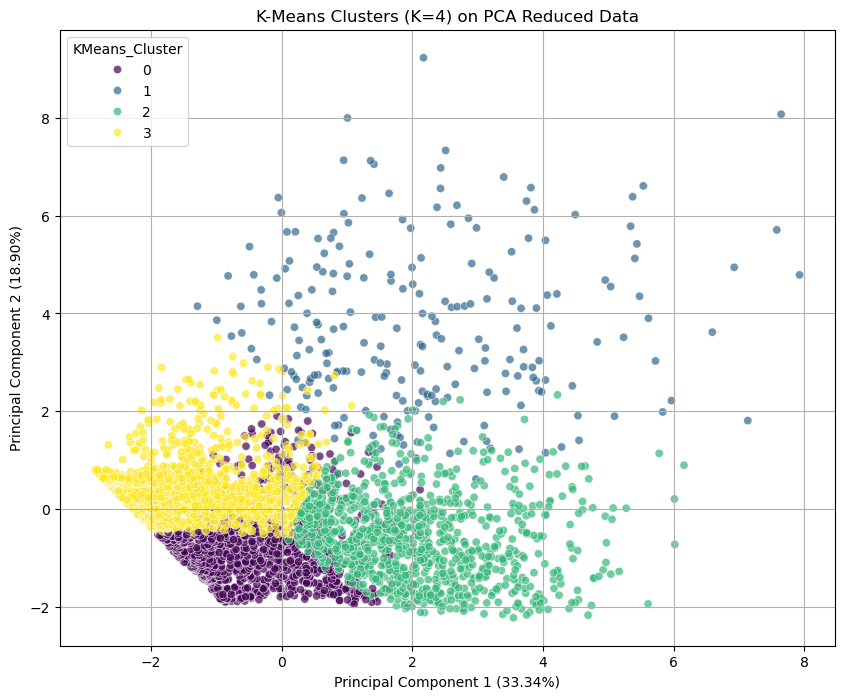

In [56]:
# K-Means Visualization
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', data=df_pca, palette='viridis', legend='full', alpha=0.7)
plt.title(f'K-Means Clusters (K={optimal_k}) on PCA Reduced Data')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.show()

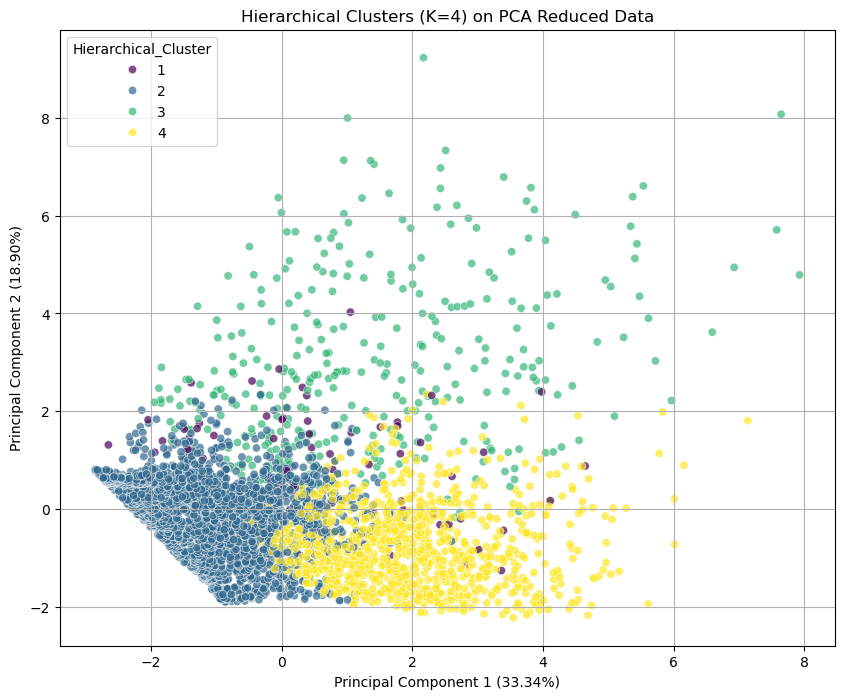

In [57]:
# Hierarchical Clustering Visualization
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Hierarchical_Cluster', data=df_pca, palette='viridis', legend='full', alpha=0.7)
plt.title(f'Hierarchical Clusters (K={optimal_k}) on PCA Reduced Data')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.show()

In [58]:
# DBSCAN Visualization
plt.figure(figsize=(10, 8))
# For DBSCAN, noise points (-1) are often colored differently (e.g., grey).
# This prepares a palette where -1 is grey and other clusters get distinct colors.
unique_dbscan_clusters = df_pca['DBSCAN_Cluster'].unique()
sorted_dbscan_clusters = np.sort(unique_dbscan_clusters)


<Figure size 1000x800 with 0 Axes>

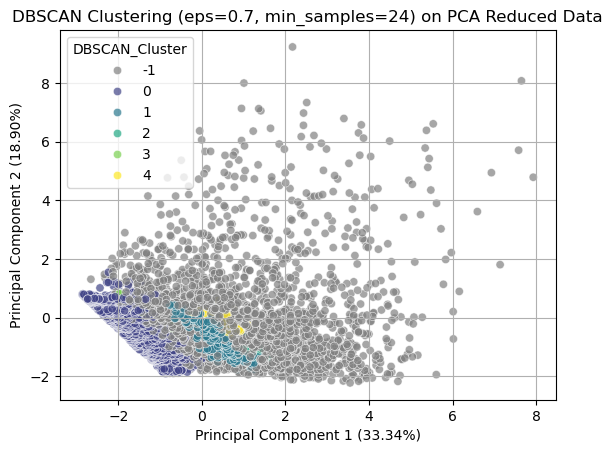

In [59]:
colors_map_dbscan = {cluster: plt.cm.viridis(i/ (len(sorted_dbscan_clusters) - 1)) if cluster != -1 else (0.5, 0.5, 0.5, 1.0) for i, cluster in enumerate(sorted_dbscan_clusters)}
# Ensure consistent mapping for actual cluster indices
plot_palette_dbscan = [colors_map_dbscan[c] for c in sorted_dbscan_clusters]

sns.scatterplot(x='PC1', y='PC2', hue='DBSCAN_Cluster', data=df_pca, palette=plot_palette_dbscan,
                legend='full', alpha=0.7, hue_order=sorted_dbscan_clusters)
plt.title(f'DBSCAN Clustering (eps={eps_val}, min_samples={min_samples_dbscan}) on PCA Reduced Data')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.show()

Evaluation and Performance Metrics:

Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.


In [60]:
print("\n--- Evaluation and Performance Metrics Summary ---")
print(f"K-Means (K={optimal_k}) Silhouette Score: {silhouette_avg_kmeans:.3f}")
print(f"Hierarchical (K={optimal_k}) Silhouette Score: {silhouette_avg_hierarchical:.3f}")
# This line will print the DBSCAN silhouette score, or raise an error if not calculable.
print(f"DBSCAN (eps={eps_val}, min_samples={min_samples_dbscan}) Silhouette Score: {silhouette_avg_dbscan:.3f}")



--- Evaluation and Performance Metrics Summary ---
K-Means (K=4) Silhouette Score: 0.242
Hierarchical (K=4) Silhouette Score: 0.280
DBSCAN (eps=0.7, min_samples=24) Silhouette Score: 0.287


Evaluation and Performance Metrics Summary:

The quality of the clustering algorithms (K-Means, Hierarchical, and DBSCAN) was evaluated using the Silhouette Score, which ranges from -1 to 1. A higher score (closer to 1) indicates better-defined and more separated clusters, while scores near 0 suggest overlapping clusters, and negative scores indicate that data points might be assigned to the wrong cluster.

Based on your execution, here are the specific scores:

K-Means Clustering (with K=4): Achieved a Silhouette Score of 0.242.
Hierarchical Clustering (with K=4, 'ward' linkage): Achieved a Silhouette Score of 0.280.
DBSCAN Clustering (with eps=0.7, min_samples=24): Achieved a Silhouette Score of 0.287.
Comparative Analysis and Insights:

Overall Scores: All three algorithms yielded relatively low, but positive, Silhouette Scores (between 0.24 and 0.29). This suggests that while some structure was found, the clusters might be somewhat overlapping or not as distinctly separated as one might hope for in an ideal dataset. Scores in this range are common in real-world, complex datasets.
Hierarchical and DBSCAN slightly better: Hierarchical and DBSCAN clustering slightly outperformed K-Means in terms of Silhouette Score in this specific run.
Hierarchical Clustering (0.280) shows a marginal improvement over K-Means. This could indicate that the 'ward' linkage method was slightly better at identifying natural groupings in this data structure compared to K-Means' spherical assumptions for a fixed number of clusters.
DBSCAN (0.287) yielded the highest score among the three. DBSCAN's strength lies in its ability to discover arbitrarily shaped clusters and identify noise points (-1) that do not fit well into any dense cluster. The Silhouette Score for DBSCAN is calculated only on the points assigned to a cluster (excluding noise), which can sometimes contribute to a relatively higher score as it's not penalizing "unclusterable" points.

Conclusion:

While no algorithm achieved a very high Silhouette Score (closer to 1), all three successfully identified some level of structure within the EastWestAirlines customer data. The scores suggest that the customer segments, while present, might not be perfectly distinct or might exhibit some overlap in their characteristics. DBSCAN, in this instance, provided the most favorable score, potentially due to its ability to handle irregularly shaped clusters and noise. Further experimentation with different parameters for all algorithms, especially eps and min_samples for DBSCAN, could lead to even better-defined clusters.